In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.metrics import mean_absolute_error, mean_squared_error

#load the data, and inspect it
aacb_data = pd.read_csv("C:/Users/small/Downloads/AACB.csv")
aacb_data.info()
aacb_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ticker  152 non-null    object 
 1   date    152 non-null    object 
 2   open    152 non-null    float64
 3   high    152 non-null    float64
 4   low     152 non-null    float64
 5   close   152 non-null    float64
dtypes: float64(4), object(2)
memory usage: 7.2+ KB


,ticker,date,open,high,low,close
0,AACB,2025-04-07,10.10,10.10,9.88,9.880
1,AACB,2025-04-09,9.90,9.90,9.90,9.900
2,AACB,2025-04-10,9.89,9.89,9.89,9.890
3,AACB,2025-04-11,9.88,9.89,9.88,9.885
4,AACB,2025-04-14,9.89,9.91,9.89,9.900


In [15]:
#so far from using info it can be taken that ticker has no value the analysis and so will be droppped
#date is given as object and will be converted to datetime for a time index
aacb_data['date']=pd.to_datetime(aacb_data['date'])
#sort by time
aacb_data=aacb_data.sort_values('date')
#now set as index
aacb_data=aacb_data.set_index('date')

#inspect changes
aacb_data.head()

,ticker,open,high,low,close
date,,,,,
2025-04-07,AACB,10.10,10.10,9.88,9.880
2025-04-09,AACB,9.90,9.90,9.90,9.900
2025-04-10,AACB,9.89,9.89,9.89,9.890
2025-04-11,AACB,9.88,9.89,9.88,9.885
2025-04-14,AACB,9.89,9.91,9.89,9.900


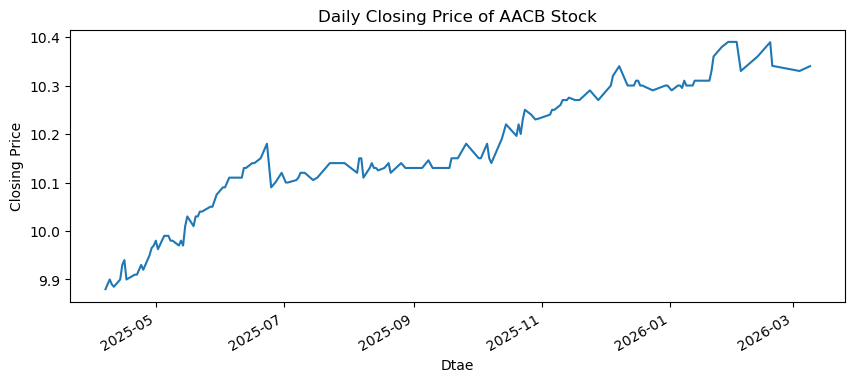

np.int64(0)

In [16]:
#plotting follows to check for trends, calm vs volatility, and sudden jumps
aacb_data['close'].plot(figsize=(10,4))
plt.title('Daily Closing Price of AACB Stock')
plt.xlabel('Dtae')
plt.ylabel('Closing Price')
plt.show()

#next comes cleaning, check for duplicates, missing timestamps, or non--monotonic index
aacb_data.index.is_monotonic_increasing#should return tRue because the intervals at which
#the data was taken should be the same or monotonous
aacb_data.index.duplicated().sum()#should return 0

**Interpreting the graph, the closing price shows:**

1. Theres an overall upward trend over time (changing mean, and variance)
2. small day to day flactuations
3. no repeating pattern seasonally
4. and low volatility

This statistially means a changing Mean and so models like ARIMA cannot be directly fitted with this data (constant variance,constant mean in other words stationarity is required).

 **Compute Daily Returns**
 Daily returns answers the question how much did the prices cange relative to yesterday? By what fraction did the price change from yesterday's close change to today's close? With flactuations revolving around zero, meaning the changes balance therefore no persistent upward or downward movement. Making them perfect for erformance analysis, volatility assessment, modeling.

In [17]:
#so the next step is calculating or computing daily returns
#close is used for price series due to being a summation of the market that day
aacb_data['returns'] = (aacb_data['close'] - aacb_data['close'].shift(1))/aacb_data['close'].shift(1)#shift in this case moves the series down by one

#inspect
aacb_data[['close','returns']].head()

,close,returns
date,,
2025-04-07,9.880,NaN
2025-04-09,9.900,0.002024
2025-04-10,9.890,-0.001010
2025-04-11,9.885,-0.000506
2025-04-14,9.900,0.001517


The above output is expected, NaN initially for example, theres no day before therefore mathematically undefined (dividing by zero), and small positive/negative numbers for returns
to show the flactuations mentioned prior of which all are very much close to zero.
The next step from ere is to plot these to see if they display the desired behavior statistically in terms of mean, and variance.

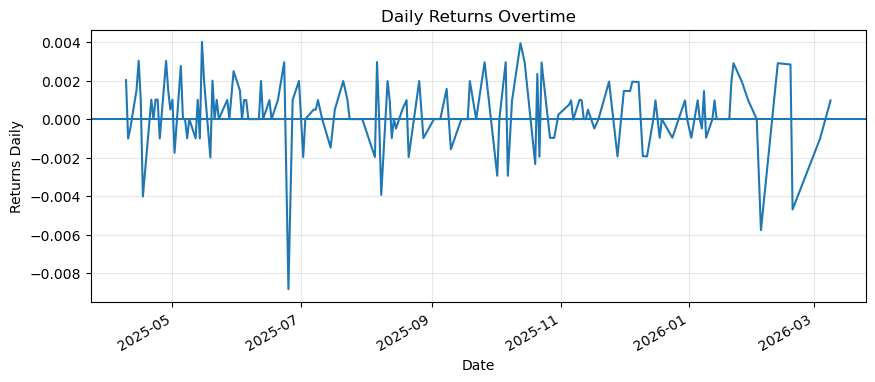

In [18]:
#plotting daily returns
aacb_data['returns'].plot(figsize=(10,4))
plt.axhline(0)
plt.title('Daily Returns Overtime')
plt.xlabel('Date')
plt.ylabel('Returns Daily')
plt.grid(alpha=0.3)
plt.show()

**Interpretation of The Graph**
1. The horizontal line shows zero
2. The spikes above it are increases in the price and those below are drops, whicn are also positive or negative returns
3. This shows exactly what was desired, positives and negatives balance, with no upward or downward trend man constant Mean, approximately.

Most values are between + or - 0.2%, with occasionally large spikes, while the varience the entire time remains stable rouhgly wich is also good for the model choice.
The confirmationn below should print something very close to zero as te mean looking at the theoretical take above.

In [19]:
#confirmation
aacb_data['returns'].std()
aacb_data['returns'].mean()

np.float64(0.0003030001677970552)

In [20]:
#drop the NaN along with useless columns
aacb_data=aacb_data.dropna()
#drop the ticker column
aacb_data=aacb_data.drop(columns=['ticker'])

In [21]:
#confirm the drops
aacb_data.head()

,open,high,low,close,returns
date,,,,,
2025-04-09,9.90,9.90,9.90,9.900,0.002024
2025-04-10,9.89,9.89,9.89,9.890,-0.001010
2025-04-11,9.88,9.89,9.88,9.885,-0.000506
2025-04-14,9.89,9.91,9.89,9.900,0.001517
2025-04-15,9.94,9.94,9.89,9.930,0.003030


 **Test for Stationarity (Augmented Dickey-Fuller)**
 Te ADF investigates whether a time seris has a unit root
This can be taken in various hypotheses:
1. Null:The series is non-stationary
2. Alternative: the series is stationary
And the gaol is to ap;ly to retursn because of their stationary behavior, here the goal is to reject null.

In [22]:
returns=aacb_data['returns'].dropna()
adf_results=adfuller(returns)#verifies if a series is non-stationary returning a tuple
print(adf_results)

(np.float64(-12.491540102663048), np.float64(2.938006824424475e-23), 1, 149, {'1%': np.float64(-3.4750180242954167), '5%': np.float64(-2.8811408028842043), '10%': np.float64(-2.577221358046935)}, np.float64(-1347.5322697534482))


ADf, as seen above gives a tuple of whoch below w will select a few entries from it. 

In [23]:
#ADF
adf_stats=adf_results[0]#first in the tuple
print('ADF Statistic:', adf_stats)#this should be a negative to show stationarity
p_value = adf_results[1]
print('P-value:', p_value)#if  <0.05 reject null hypothesis meaning stationary, othrwise fail to reject and non-stationary
c_values=adf_results[4]
print('critical_values:',c_values)#SHOULD PRINT A DICTIONARY TLLING HOW NEGATIVE ADF_STATISTIC MUST BE TO REJECT THE NULL

ADF Statistic: -12.491540102663048
P-value: 2.938006824424475e-23
critical_values: {'1%': np.float64(-3.4750180242954167), '5%': np.float64(-2.8811408028842043), '10%': np.float64(-2.577221358046935)}


**Interpretation**
The ADF_statistics is at a level called extrmely negative whic highly encourages rejecting te null , it is also lower than all the critical values at all levels another reason to reject.

-12.49<-3.48<-2.88<-2.58, and lastly the p_value is very small compared to 0.05 valued at 2.94*10**-23, so again strong rejection.

This leads to a conclusion that te sseries is stationary, allowing for the use of ARIMA. So next is modeling, tere should be another step here but that will be observed later for experimental reasons.
What appens if one models returns wit minimal assumptions?
This question will be answred by comparing:
1. using te same trainand test data sets
2. error matric

In [24]:
#train-test split 
# Drop NaN from returns (important)
ts_data = aacb_data['returns'].dropna()

# Determine split index
split_index = int(len(ts_data) * 0.8)#finds length then gets 0.8 fracton of it

# Time-based split
train = ts_data.iloc[:split_index]#selects everything till te 0.8 split
test = ts_data.iloc[split_index:]#selects anything after the split point or 0.8 of the data set

#output lengths of each
print("Train size:", len(train))
print("Test size:", len(test))

Train size: 120
Test size: 31


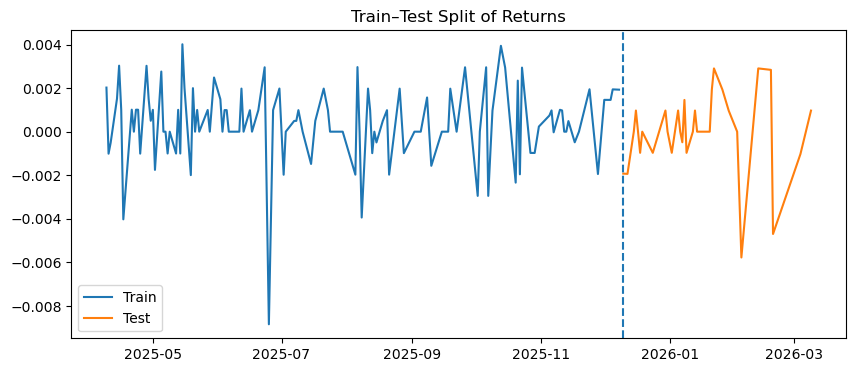

In [25]:
#plot to see if its sensible, train data should be on the left and test data on the right
plt.figure(figsize=(10, 4))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.axvline(test.index[0], linestyle='--')
plt.title("Train–Test Split of Returns")
plt.legend()
plt.show()

The return series was divided into training and testing sets using a time-based split.
Therefore, fractions of the above splits are approximately 80% and 20% in favor of training data(120 and 31). And train data being on the right is because of forecasting, the data of the past forecast for the future which is what the model will do.

In [26]:
#fitting a model without ACF/PACF
from statsmodels.tsa.arima.model import ARIMA

# Example: ARIMA(0,0,0)
model = ARIMA(train, order=(0,0,0))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                  120
Model:                          ARIMA   Log Likelihood                 591.846
Date:                Fri, 13 Mar 2026   AIC                          -1179.692
Time:                        18:01:48   BIC                          -1174.117
Sample:                             0   HQIC                         -1177.428
                                - 120                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      2.063      0.039    1.89e-05       0.001
sigma2      3.045e-06   2.34e-07     13.041      0.000    2.59e-06     3.5e-06
Ljung-Box (L1) (Q):                   7.83   Jarque-

C:\Users\small\.conda\envs\ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\small\.conda\envs\ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\small\.conda\envs\ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


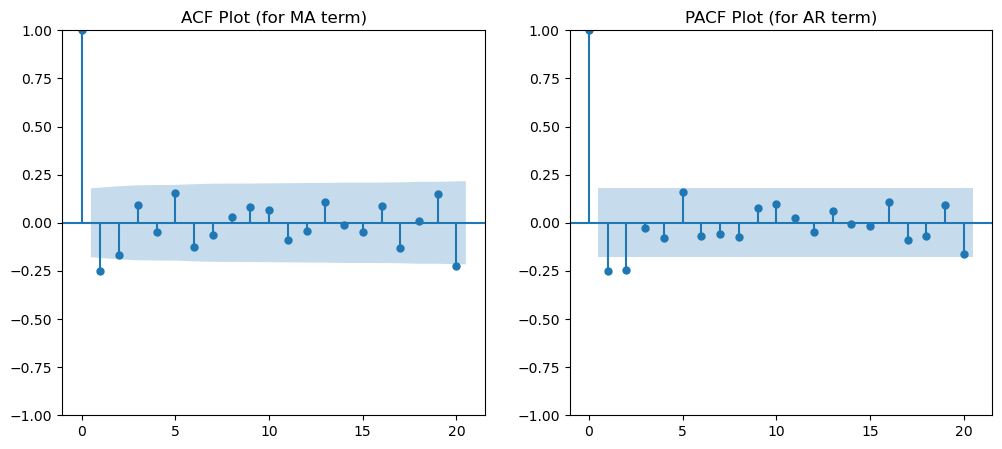

In [27]:
#using pacf and acf wic communicate whether returns have memory, 
#AR or MA which components to use

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
#acf plot
plt.subplot(121)
plot_acf(train, lags=20, ax=plt.gca())
plt.title("ACF Plot (for MA term)")
#pacf plot
plt.subplot(122)
plot_pacf(train, lags=20, ax=plt.gca())
plt.title("PACF Plot (for AR term)")

plt.show()


**Interprtation**

1. All lags xcept lag 0 are within reach of te blueline wich is known as an area of 95% confidence in trms of past retrunsnot having a statistically predictable significant impact on future returns.
2. ACF(moving average): theres a slight poke of lag 1 and 20, but besides that the others are in te blue colord band. This can be said to mean that theres no clear cut-off after any lag therefore MA is unnecessary,(likely).
3. PACF(autoregressive): The Partial Auto Corrrelation Function sows negative correlation for 1 and 2 maning this is also likely unnecessary.

The conclusion is ARIMA(0, 0, 0) IS MOST SUITABLE.

In [28]:
from statsmodels.tsa.arima.model import ARIMA

# Example orders; replace with what ACF/PACF suggest
p = 2  # from PACF
d = 0  # stationary
q = 1  # from ACF

model = ARIMA(train, order=(p,d,q))
model_fit = model.fit()
print(model_fit.summary())
pred = model_fit.forecast(steps=len(test))
pred.index=test.index # align predictions with test period

C:\Users\small\.conda\envs\ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\small\.conda\envs\ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\small\.conda\envs\ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                  120
Model:                 ARIMA(2, 0, 1)   Log Likelihood                 599.809
Date:                Fri, 13 Mar 2026   AIC                          -1189.617
Time:                        18:01:49   BIC                          -1175.680
Sample:                             0   HQIC                         -1183.957
                                - 120                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      3.410      0.001       0.000       0.001
ar.L1         -0.1968      0.342     -0.575      0.566      -0.868       0.474
ar.L2         -0.2200      0.154     -1.431      0.1

C:\Users\small\.conda\envs\ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\small\.conda\envs\ds\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


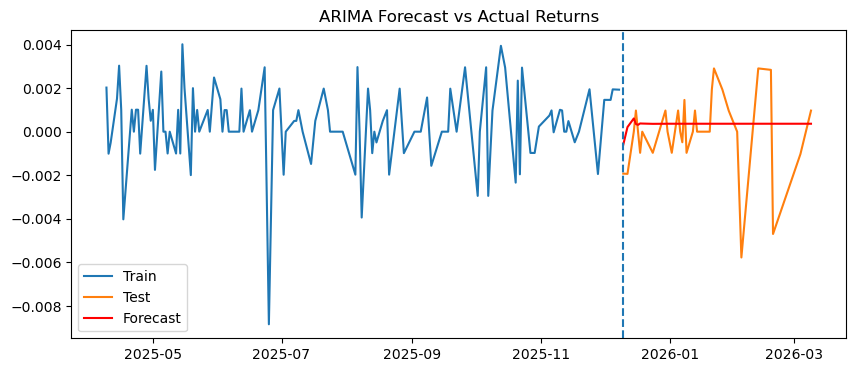

MSE: 3.49174037149064e-06


In [29]:
plt.figure(figsize=(10,4))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(pred, label='Forecast', color='red')
plt.axvline(test.index[0], linestyle='--')
plt.title("ARIMA Forecast vs Actual Returns")
plt.legend()
plt.show()

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(test, pred)
print("MSE:", mse)